In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings("ignore")

# Load the Titanic dataset
titanic = sns.load_dataset("titanic")

# Display the first 5 rows of the dataset
display(titanic.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [25]:
# Check for missing data
print("\nMissing values per column:")
display(titanic.isnull().sum())

# Check data types
print("\nData types:")
display(titanic.info())

# Examine class imbalance in survival outcomes
print("\nSurvival outcome distribution:")
display(titanic['survived'].value_counts(normalize=True))



Missing values per column:


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None


Survival outcome distribution:


survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [21]:
survival_counts = titanic['survived'].value_counts()
survival_proportions = titanic['survived'].value_counts(normalize=True)

print("Survival Counts:")
print(survival_counts)
print("\nSurvival Proportions:")
print(survival_proportions)

Survival Counts:
survived
0    549
1    342
Name: count, dtype: int64

Survival Proportions:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [35]:
# ── Q1: Data Integrity ────────────────────────────────────────────────────────
print(titanic[["survived","sex","age","pclass","fare"]].describe())
print("\nMissing:\n", titanic.isnull().sum()[titanic.isnull().sum() > 0])
print("\nSurvival rate:", titanic.survived.mean().round(3))
print("\nBy sex:\n",   titanic.groupby("sex").survived.mean().round(3))
print("\nBy class:\n", titanic.groupby("pclass").survived.mean().round(3))

         survived         age      pclass        fare
count  891.000000  714.000000  891.000000  891.000000
mean     0.383838   29.699118    2.308642   32.204208
std      0.486592   14.526497    0.836071   49.693429
min      0.000000    0.420000    1.000000    0.000000
25%      0.000000   20.125000    2.000000    7.910400
50%      0.000000   28.000000    3.000000   14.454200
75%      1.000000   38.000000    3.000000   31.000000
max      1.000000   80.000000    3.000000  512.329200

Missing:
 age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Survival rate: 0.384

By sex:
 sex
female    0.742
male      0.189
Name: survived, dtype: float64

By class:
 pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64


In [37]:
# ── Q2: Features & Models ─────────────────────────────────────────────────────
titanic["is_female"] = (titanic.sex == "female").astype(int)
titanic["is_child"]  = (titanic.age < 15).astype(float)
titanic["fare_log"]  = np.log1p(titanic.fare)
 
X = titanic[["pclass","is_female","age","sibsp","parch","fare_log","is_child"]]
y = titanic.survived
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
def pipe(model):
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc",  StandardScaler()),
                     ("m",   model)])
 
models = {
    "Logistic Regression": pipe(LogisticRegression(max_iter=1000, random_state=42)),
    "Random Forest":       pipe(RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
}
 
print("\n── CV Results ──")
for name, m in models.items():
    scores = {s: cross_val_score(m, X, y, cv=cv, scoring=s)
              for s in ["accuracy","roc_auc","f1"]}
    print(f"\n{name}")
    for s, v in scores.items():
        print(f"  {s}: {v.mean():.3f} ± {v.std():.3f}")


── CV Results ──

Logistic Regression
  accuracy: 0.801 ± 0.014
  roc_auc: 0.858 ± 0.021
  f1: 0.728 ± 0.025

Random Forest
  accuracy: 0.834 ± 0.019
  roc_auc: 0.874 ± 0.021
  f1: 0.761 ± 0.031


In [39]:
# Fit for coefficients / importances
for m in models.values():
    m.fit(X, y)
 
coef = models["Logistic Regression"].named_steps["m"].coef_[0]
fi   = models["Random Forest"].named_steps["m"].feature_importances_
print("\n── LR Odds Ratios ──")
for f, c in sorted(zip(X.columns, coef), key=lambda x: -abs(x[1])):
    print(f"  {f:<12} OR = {np.exp(c):.3f}")


── LR Odds Ratios ──
  is_female    OR = 3.714
  pclass       OR = 0.508
  sibsp        OR = 0.554
  fare_log     OR = 1.503
  is_child     OR = 1.455
  age          OR = 0.731
  parch        OR = 0.803


In [41]:
# Probabilities for ROC
lr_p = cross_val_predict(models["Logistic Regression"], X, y, cv=cv, method="predict_proba")[:,1]
rf_p = cross_val_predict(models["Random Forest"],       X, y, cv=cv, method="predict_proba")[:,1]
 
print("\n── Classification Report (LR) ──")
print(classification_report(y, (lr_p > 0.5).astype(int), target_names=["Died","Survived"]))


── Classification Report (LR) ──
              precision    recall  f1-score   support

        Died       0.82      0.87      0.84       549
    Survived       0.77      0.70      0.73       342

    accuracy                           0.80       891
   macro avg       0.79      0.78      0.79       891
weighted avg       0.80      0.80      0.80       891



<Figure size 700x500 with 0 Axes>

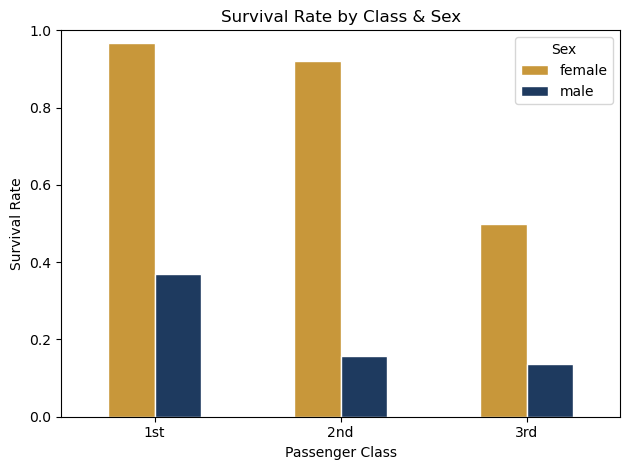

In [63]:
def save(name):
    plt.tight_layout()
    plt.savefig(f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
 
# ── Figure 1: Survival rate by Class × Sex ────────────────────────────────────
plt.figure(figsize=(7, 5))
titanic.groupby(["pclass","sex"]).survived.mean().unstack().plot(
    kind="bar", color=["#C8973A","#1E3A5F"], edgecolor="white")
plt.title("Survival Rate by Class & Sex")
plt.xlabel("Passenger Class"); plt.ylabel("Survival Rate")
plt.xticks([0,1,2], ["1st","2nd","3rd"], rotation=0)
plt.ylim(0, 1); plt.legend(title="Sex")
save("fig1_class_sex")

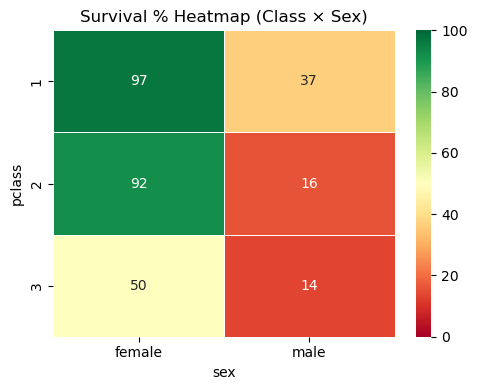

In [65]:
# ── Figure 2: Survival heatmap ────────────────────────────────────────────────
plt.figure(figsize=(5, 4))
pivot = titanic.groupby(["pclass","sex"]).survived.mean().unstack() * 100
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100, linewidths=0.5)
plt.title("Survival % Heatmap (Class × Sex)")
save("fig2_heatmap")

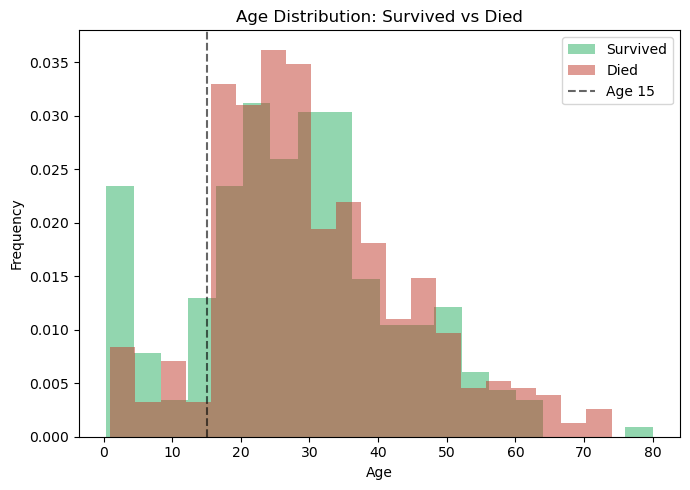

In [67]:
# ── Figure 3: Age distribution ────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
for val, label, col in [(1,"Survived","#27AE60"),(0,"Died","#C0392B")]:
    titanic[titanic.survived==val].age.dropna().plot(
        kind="hist", bins=20, alpha=0.5, color=col, density=True, label=label)
plt.axvline(15, color="k", ls="--", alpha=0.6, label="Age 15")
plt.title("Age Distribution: Survived vs Died")
plt.xlabel("Age"); plt.legend()
save("fig3_age")

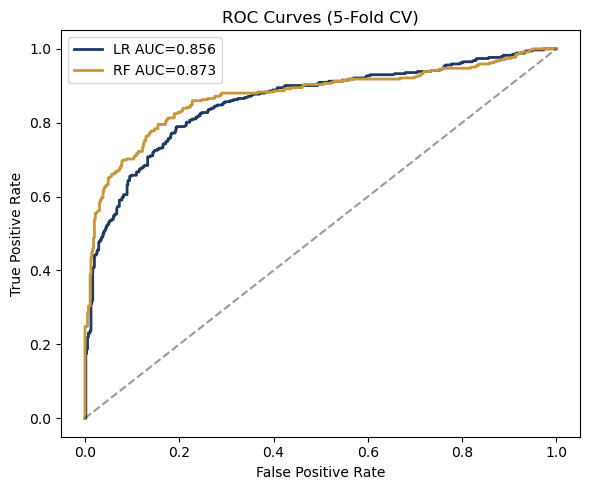

In [69]:
# ── Figure 4: ROC curves ──────────────────────────────────────────────────────
plt.figure(figsize=(6, 5))
for proba, name, col in [(lr_p,"LR","#1E3A5F"),(rf_p,"RF","#C8973A")]:
    fpr, tpr, _ = roc_curve(y, proba)
    plt.plot(fpr, tpr, color=col, lw=2, label=f"{name} AUC={auc(fpr,tpr):.3f}")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.title("ROC Curves (5-Fold CV)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend()
save("fig4_roc")

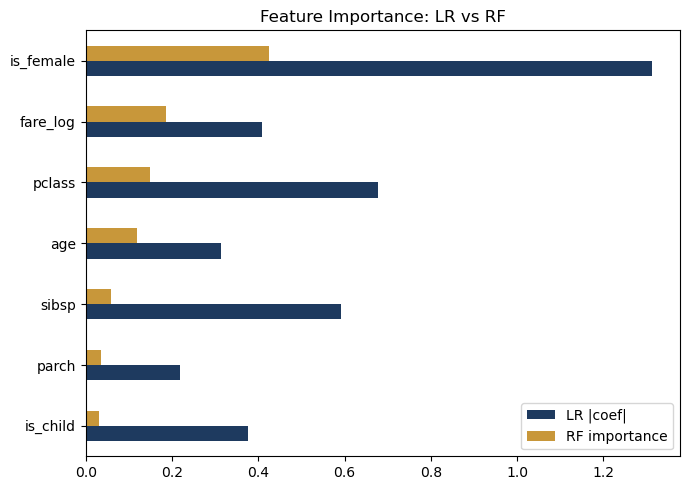

In [71]:
 # ── Figure 5: Feature importance ──────────────────────────────────────────────
plt.figure(figsize=(7, 5))
feat_titanic = pd.DataFrame({"LR |coef|": np.abs(coef), "RF importance": fi},
                        index=X.columns).sort_values("RF importance")
feat_titanic.plot(kind="barh", color=["#1E3A5F","#C8973A"], ax=plt.gca())
plt.title("Feature Importance: LR vs RF")
save("fig5_features")

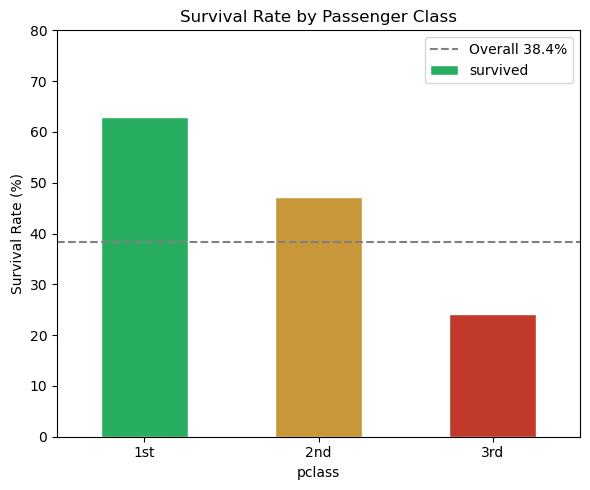

In [73]:
 # ── Figure 6: Class survival rate ─────────────────────────────────────────────
plt.figure(figsize=(6, 5))
rates = titanic.groupby("pclass").survived.mean() * 100
rates.plot(kind="bar", color=["#27AE60","#C8973A","#C0392B"], edgecolor="white")
plt.axhline(titanic.survived.mean()*100, color="grey", ls="--",
            label=f"Overall {titanic.survived.mean()*100:.1f}%")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate (%)"); plt.ylim(0, 80)
plt.xticks([0,1,2], ["1st","2nd","3rd"], rotation=0)
plt.legend()
save("fig6_class")